Classification of mitotic phases in histopathology data
===================================================

Authors : 'Elyesse and Alexandre'

Supervision : 'Thomas and Raphaël'

Mitotic activity is a central indicator of tumor proliferation and prognosis. The most relevant information used today by pathologists is the count of mitotic events in selected regions. Identifying precise counts manually at the level of the entire tissue section is not possible,
as in a single slide there are hundreds of thousands of individual cells. AI solutions to automate the detection and counting process have been proposed, and the CBIO has developed solutions that are currently state-of-the-art (1st and 2nd place in two recent competitions).

However, we believe that more information on cell division could be leveraged by not only identifying and counting dividing cells, but also by dertermining the precise mitotic phase. Such an analysis could point to specific mechanisms of deregulation, potentially linked to clinical outcomes.

In this project, we propose to train Neural Networks to identify mitotic phases in Whole Slide Images.

Setup & configuration
===================================================

In [1]:
%matplotlib inline

In [2]:
import zipfile
import os
from google.colab import files

# Path to the zip file.
zip_file_path = 'data.zip'

print(f"Please upload the file '{zip_file_path}'.")
uploaded = files.upload()

if zip_file_path not in uploaded:
    print("No 'data.zip' file uploaded. Extraction cannot proceed.")
else:
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # Extract to the current directory
            zip_ref.extractall('.')
        print(f"'{zip_file_path}' successfully extracted to the current directory.")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")

Please upload the file 'data.zip'.


Saving data.zip to data.zip
'data.zip' successfully extracted to the current directory.


Imports
===================================================


In [3]:
!pip install -q torchstain torchcam grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", bu

In [1]:
# --- 1. Standard & System Imports ---
import os
import random
import time
import copy
from pathlib import Path

# --- 2. Data & Image Manipulation ---
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import seaborn as sns

# --- 3. PyTorch & Torchvision ---
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.transforms import v2, InterpolationMode

# --- 4. Specific Libraries (Histopathology & Explainability) ---
import torchstain          # Color normalization
from torchcam.methods import SmoothGradCAMpp # For final visualization
from torchcam.utils import overlay_mask

# --- 5. Sklearn (Metrics) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from scipy.stats import entropy

# --- 6. Grad-CAM (XAI) ---
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- Graphic Configuration ---
sns.set_theme(style="whitegrid") # For more aesthetic plots
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# 1. Load and copy to avoid altering the original
df_stats = pd.read_csv('data/AMI-BR.csv').copy()

# 2. Create agreement analysis columns
# Phase agreement (expert 1 vs expert 2)
df_stats['phase_agreement'] = df_stats['expert1_label'] == df_stats['expert2_label']

# Calculate the number of experts who voted "Atypical = True"
# Sum booleans (True=1, False=0)
atypical_cols = ['expert1_atypical', 'expert2_atypical', 'expert3_atypical']
df_stats['nb_atypical_votes'] = df_stats[atypical_cols].sum(axis=1)

# Define confidence levels for atypia
df_stats['atypical_consensus'] = df_stats['nb_atypical_votes'] == 3
df_stats['atypical_majority'] = df_stats['nb_atypical_votes'] >= 2
df_stats['atypical_disagreement'] = (df_stats['nb_atypical_votes'] > 0) & (df_stats['nb_atypical_votes'] < 3)

# 3. Display Global Statistics
total = len(df_stats)
print(f"--- DATASET ANALYSIS ({total} cells) ---")

# Phase agreement
match_rate = df_stats['phase_agreement'].mean() * 100
print(f"\n[PHASES] Expert 1 / Expert 2 Agreement : {match_rate:.2f}%")

# Atypia analysis (Majority vs Consensus)
print("\n[ATYPIA] Vote distribution :")
atypical_stats = {
    "Consensus (3/3 experts)": df_stats['atypical_consensus'].sum(),
    "Simple majority (>= 2/3)": df_stats['majority_atypical'].sum(), # Uses original column
    "Total disagreement (1 or 2 votes)": df_stats['atypical_disagreement'].sum(),
    "Strictly Normal (0/3 votes)": (df_stats['nb_atypical_votes'] == 0).sum()
}

for label, count in atypical_stats.items():
    print(f"- {label}: {count} ({count/total*100:.1f}%)")

# 4. Top 5 phase confusions (when experts disagree)
print("\n[CONFUSIONS] Top 5 most frequent phase disagreements :")
disagreements = df_stats[df_stats['phase_agreement'] == False]
confusion = disagreements.groupby(['expert1_label', 'expert2_label']).size().sort_values(ascending=False)
print(confusion.head(5))

# 5. Class distribution (based on majority for atypia)
print("\n[CLASSES] Final distribution (based on Expert 1) :")
print(df_stats['expert1_label'].value_counts(normalize=True) * 100)

--- DATASET ANALYSIS (3720 cells) ---

[PHASES] Expert 1 / Expert 2 Agreement : 70.65%

[ATYPIA] Vote distribution :
- Consensus (3/3 experts): 412 (11.1%)
- Simple majority (>= 2/3): 832 (22.4%)
- Total disagreement (1 or 2 votes): 812 (21.8%)
- Strictly Normal (0/3 votes): 2496 (67.1%)

[CONFUSIONS] Top 5 most frequent phase disagreements :
expert1_label     expert2_label  
NMF prometaphase  NMF metaphase      244
                  AMF segregation    131
NMF metaphase     AMF segregation    121
NMF prometaphase  NMF ring shape     112
                  AMF other           53
dtype: int64

[CLASSES] Final distribution (based on Expert 1) :
expert1_label
NMF prometaphase          41.048387
NMF metaphase             36.263441
AMF other                  6.854839
NMF anaphase-telophase     6.801075
AMF segregation            4.139785
AMF multipolar             1.908602
AMF bipolar assymetric     1.586022
NMF ring shape             1.397849
Name: proportion, dtype: float64


Comparison of Expert 2 labels (true) vs Expert 1 (predicted for comparison) on 3720 samples of the full dataset :
                        precision    recall  f1-score   support

AMF bipolar assymetric       0.33      0.59      0.43        59
        AMF multipolar       0.72      0.39      0.51        71
             AMF other       0.51      0.47      0.49       255
       AMF segregation       0.25      0.78      0.38       154
NMF anaphase-telophase       0.80      0.66      0.72       253
         NMF metaphase       0.78      0.87      0.83      1349
      NMF prometaphase       0.95      0.62      0.75      1527
        NMF ring shape       0.23      0.65      0.33        52

              accuracy                           0.71      3720
             macro avg       0.57      0.63      0.55      3720
          weighted avg       0.80      0.71      0.73      3720



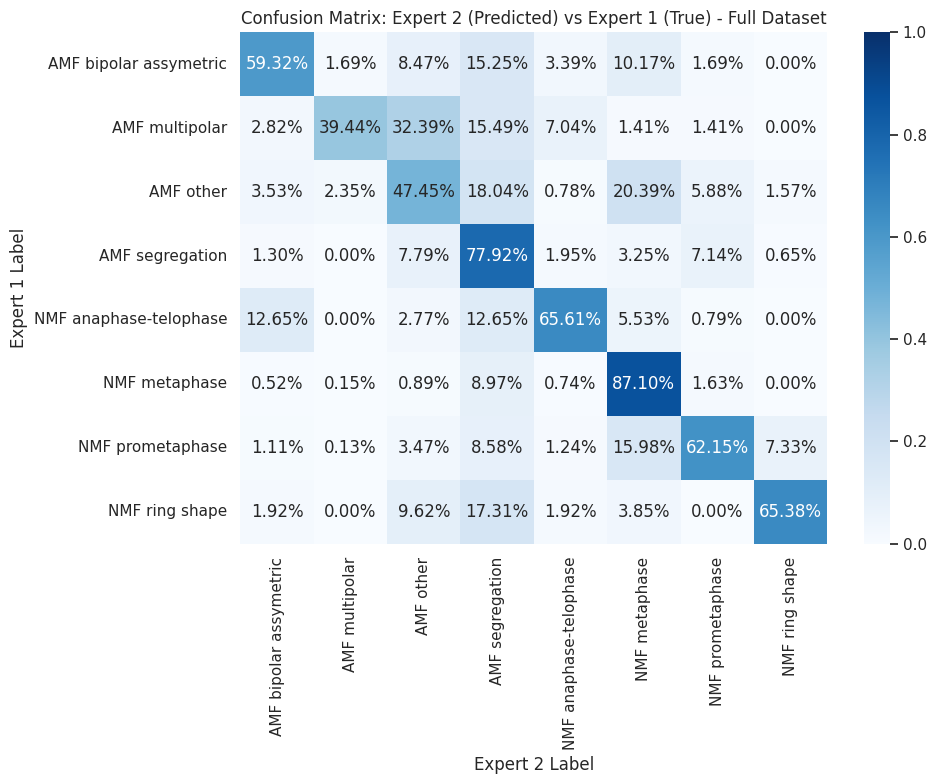

In [3]:
# 1. Extract labels from expert 1 and expert 2 from the full DataFrame
expert1_labels = df_stats['expert1_label'].values
expert2_labels = df_stats['expert2_label'].values

# 2. Use the class_name -> index mapping based on ALL unique classes in the dataset.
# class_names was previously defined as sorted(mitosis_frame['expert1_label'].unique())
all_class_names = sorted(df_stats['expert1_label'].unique())
class_to_idx = {cls_name: i for i, cls_name in enumerate(all_class_names)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Convert string labels to numerical labels using the mapping
numerical_expert1_labels = np.array([class_to_idx[label] for label in expert1_labels if label in class_to_idx])
numerical_expert2_labels = np.array([class_to_idx[label] for label in expert2_labels if label in class_to_idx])

# Ensure lengths are identical after filtering if necessary
# (Normally, there should be no difference if class_to_idx is well-generated for all classes)
if len(numerical_expert1_labels) != len(numerical_expert2_labels):
    print("Warning: Numerical label lists for expert 1 and expert 2 have different lengths.")
    min_len = min(len(numerical_expert1_labels), len(numerical_expert2_labels))
    numerical_expert1_labels = numerical_expert1_labels[:min_len]
    numerical_expert2_labels = numerical_expert2_labels[:min_len]

# Get the unique numerical classes present in both experts' labels
unique_labels_present = sorted(list(np.unique(np.concatenate((numerical_expert1_labels, numerical_expert2_labels)))))

# Map these numerical labels to their corresponding class names for display
report_target_names = [idx_to_class[idx] for idx in unique_labels_present]

print(f"Comparison of Expert 2 labels (true) vs Expert 1 (predicted for comparison) on {len(numerical_expert1_labels)} samples of the full dataset :")
print(classification_report(numerical_expert1_labels, numerical_expert2_labels, target_names=report_target_names, labels=unique_labels_present))

# Confusion Matrix
# `y_true` is expert 1, `y_pred` is expert 2
cm = confusion_matrix(numerical_expert1_labels, numerical_expert2_labels, labels=unique_labels_present)

# Normalization to get percentages
# Handle case where axis sum is zero to avoid division by zero
cm_normalized = np.zeros_like(cm, dtype=float)
for i in range(cm.shape[0]):
    row_sum = cm[i, :].sum()
    if row_sum > 0:
        cm_normalized[i, :] = cm[i, :].astype('float') / row_sum

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=report_target_names, yticklabels=report_target_names, vmin=0, vmax=1)
plt.title("Confusion Matrix: Expert 2 (Predicted) vs Expert 1 (True) - Full Dataset")
plt.xlabel("Expert 2 Label")
plt.ylabel("Expert 1 Label")
plt.tight_layout()
plt.show()

In [4]:
CONFIG = {
    'MODE': 'NMF',  # 'AMF' (Atypical) or 'NMF' (Normal)
    'MODEL_TYPE': 'convnext_tiny', # 'tiny', 'small', 'base'
    'BATCH_SIZE': 32,
    'LR': 1e-4,
    'USE_MACENKO': True,
    'USE_SAMPLER': True,  # Essential for AMF and/or rare classes
    'NUM_WORKERS': 2,
    'TRAIN': 'full',  # 'full', 'feature_extraction' or 'fine_tune'
    'DEVICE': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# Automatic path deduction based on mode
if CONFIG['MODE'] == 'AMF':
    ROOT_DIR = 'data/patches/atypical'
    IS_ATYPICAL = True
else:
    ROOT_DIR = 'data/patches/normal'
    IS_ATYPICAL = False

# Fix the seed everywhere for reproducibility (Essential in research)
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

The dataset we are going to deal with is that of AMI-Br.

Dataset comes with a `AMI-BR.csv` file with annotations which looks like this:

``` {.sh}
,slide,dataset,uid,x,y,expert1_label,expert2_label,expert1_atypical,expert2_atypical,expert3_atypical,majority_atypical
0,002.tiff,MIDOG21,6,4422,216,NMF prometaphase,NMF metaphase,False,False,False,False
1,002.tiff,MIDOG21,7,1867,1583,AMF segregation,AMF segregation,True,True,True,True
```

Let\'s take a single image name and its annotations from the CSV, in
this case row index number 65 for MIDOG21_194.png just as an example.


In [5]:
mitosis_frame = pd.read_csv('data/AMI-BR.csv')
class_names = sorted(mitosis_frame['expert1_label'].unique())

n = 65
img_name = f"{mitosis_frame.iloc[n]['dataset']}_{mitosis_frame.iloc[n]['uid']}.png"

print('Image name: {}, expert1_label: {}'.format(img_name, mitosis_frame.iloc[n]['expert1_label']))

Image name: MIDOG21_194.png, expert1_label: NMF metaphase


Dataset class
=============


In [6]:
class MitosisDataset(Dataset):
    def __init__(self, full_df, root_dir, mode=CONFIG['MODE'], transform=None):
        """
        full_df : The complete DataFrame (AMI-BR.csv)
        root_dir : The root path for images (defined by config)
        mode : 'AMF' (Atypical) or 'NMF' (Normal)
        """
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode

        # --- INTELLIGENT FILTERING ---
        # If AMF Mode -> we keep majority_atypical == True
        # If NMF Mode -> we keep majority_atypical == False
        target_atypical = (mode == 'AMF')
        self.data = full_df[full_df['majority_atypical'] == target_atypical].reset_index(drop=True)

        # --- AUTOMATIC CLASS DETECTION ---
        # We check which labels truly exist in this subset
        # e.g.: for AMF it will find 'anaphase lagging', 'bipolar asymmetry', etc.
        self.classes = sorted(self.data['expert1_label'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.labels1 = full_df['expert1_label'].map(lambda x: self.class_to_idx[x]).values
        self.labels2 = full_df['expert2_label'].map(lambda x: self.class_to_idx[x]).values
        self.num_classes = len(self.classes)

        print(f" Dataset initialized in [{mode}] mode")
        print(f"   -> {len(self.data)} images found.")
        print(f"   -> {len(self.classes)} classes : {self.class_to_idx}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Path construction (adapted to your file format)
        img_name = f"{row['dataset']}_{row['uid']}.png"
        img_path = os.path.join(self.root_dir, img_name)

        # Loading
        image = Image.open(img_path).convert('RGB')

        # Label
        # 3. Creation of Soft Label (This is where the magic happens)
        l1 = int(self.labels1[idx])
        l2 = int(self.labels2[idx])

        # Create a zero vector [0, 0, 0, 0, 0, 0, 0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)

        # Add 0.5 for each expert's vote
        label[l1] += 0.5
        label[l2] += 0.5

        if self.transform:
            image = self.transform(image)

        return image, l1

Let\'s instantiate this class and iterate through the data samples. We
will print the sizes of first 4 samples and show their landmarks.


 Dataset initialized in [NMF] mode
   -> 2888 images found.
   -> 8 classes : {'AMF bipolar assymetric': 0, 'AMF multipolar': 1, 'AMF other': 2, 'AMF segregation': 3, 'NMF anaphase-telophase': 4, 'NMF metaphase': 5, 'NMF prometaphase': 6, 'NMF ring shape': 7}
0 (128, 128) NMF prometaphase


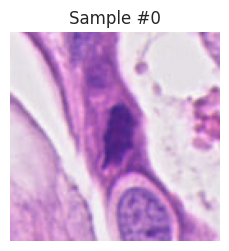

1 (128, 128) AMF segregation


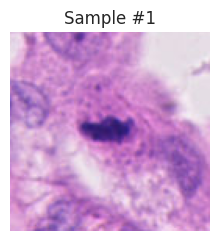

2 (128, 128) NMF metaphase


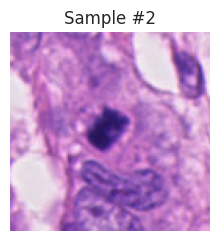

3 (128, 128) NMF prometaphase


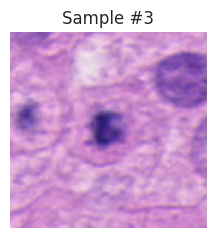

In [7]:
mitosis_dataset = MitosisDataset(mitosis_frame, root_dir=ROOT_DIR)

fig = plt.figure()

for i, (image, label) in enumerate(mitosis_dataset):
    # `label` is already an integer class index from MitosisDataset.__getitem__.
    # No need for torch.argmax().item() as it's not a soft label tensor here.
    print(i, image.size,
          mitosis_dataset.classes[label])

    ax = plt.subplot(1, 4, i + 1)
    plt.tight_layout()
    ax.set_title('Sample #{}'.format(i))
    ax.axis('off')
    plt.imshow(image)
    plt.pause(0.001)

    if i == 3:
        plt.show()
        break

Transforms
==========

In [8]:
# --- 2. AUGMENTATION MACENKO ---
class MacenkoAugment(object):
    def __init__(self, ref_images_paths, p=0.5):
        """
        ref_images_paths : List of paths to various reference images.
        p : Probability of applying the transformation.
        """
        self.refs = []
        self.p = p

        for path in ref_images_paths:
            # Read OpenCV (BGR) -> Convert RGB
            if os.path.exists(path):
              img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
              T = torchstain.normalizers.MacenkoNormalizer(backend='numpy')
              T.fit(img)
              self.refs.append(T)

    def __call__(self, img):
      # 1. Choose a random reference
      normalizer = np.random.choice(self.refs)
      # 2. Convert PIL -> Numpy
      img_np = np.array(img)
      # 3. Normalization
      norm, _, _ = normalizer.normalize(I=img_np, stains=True)
      # 4. Return PIL
      return Image.fromarray(norm.astype('uint8'))

In [9]:
# --- 4. TRANSFORMATION FACTORY (v2 Modernized & Merged Version) ---
def get_transforms(config, ref_paths=None):
    """
    Generates train/val transformations using the modern torchvision v2 API.
    Integrated with Macenko Augmentation logic.
    """

    # --- TRAINING PIPELINE ---
    train_ops = []

    # 1. Macenko Augmentation (Custom - works on PIL/Numpy)
    # We insert it BEFORE v2.ToImage() because Macenko class usually expects PIL/Numpy
    if CONFIG['USE_MACENKO'] and ref_paths is not None:
        train_ops.append(MacenkoAugment(ref_paths, p=0.5))

    # 2. New Transformations from partner
    train_ops.extend([
        v2.ToImage(),

        # Geometry: Flip and Rotation
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        # Rotation can create empty zones, fill=255 (white) for histology background
        v2.RandomRotation(degrees=180, fill=255),

        # Smart resizing to 224x224
        # scale=(0.8, 1.0): slight zoom
        # ratio=(0.95, 1.05): almost strict ratio conservation
        v2.RandomResizedCrop(
            size=(224, 224),
            scale=(0.8, 1.0),
            ratio=(0.95, 1.05),
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        ),

        # Morphological deformation (tissue elasticity)
        v2.ElasticTransform(alpha=15.0, sigma=3.0, fill=255),

        # Color adjustments (Commented out as requested)
        #v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),

        # Conversion and noise
        v2.ToDtype(torch.float32, scale=True),
        v2.GaussianNoise(mean=0.0, sigma=0.01),

        # Final normalization
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # --- VALIDATION PIPELINE ---
    val_ops = [
        v2.ToImage(),
        # For validation, simply resize cleanly to 224
        v2.Resize(size=(224, 224), interpolation=InterpolationMode.BILINEAR, antialias=True),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]

    return {
        'train': v2.Compose(train_ops),
        'val': v2.Compose(val_ops)
    }

Transfer Learning for Computer Vision
==============================================

The two major transfer learning scenarios look as follows:

-   **Finetuning the ConvNeXt**: Instead of random initialization, we
    initialize the network with a pretrained network, like the one that
    is trained on imagenet 1000 dataset. Rest of the training looks as
    usual.
-   **ConvNeXt as fixed feature extractor**: Here, we will freeze the
    weights for all of the network except that of the final fully
    connected layer. This last fully connected layer is replaced with a
    new one with random weights and only this layer is trained.


Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve is to train a model to classify
**mitotic phases**. We have about 3 720 training images.

In [10]:
# --- C. DATA PREPARATION (SPLIT) ---

# 1. Load and Initial Filtering
full_frame = pd.read_csv('data/AMI-BR.csv')

# Keep only rows that match our MODE (AMF or NMF)
# IS_ATYPICAL is defined in your config at the beginning
df_filtered = full_frame[full_frame['majority_atypical'] == IS_ATYPICAL].copy()

print(f"Total images for mode {CONFIG['MODE']} : {len(df_filtered)}")

counts = df_filtered['expert1_label'].value_counts()
print("\nInitial distribution :")
print(counts)

valid_classes = counts[counts >= 10].index
df_final = df_filtered[df_filtered['expert1_label'].isin(valid_classes)].copy()

dropped_classes = list(set(counts.index) - set(valid_classes))
if dropped_classes:
    print(f"⚠️ Classes dropped because too rare : {dropped_classes}")

target_prefix = CONFIG['MODE']

df_final = df_final[df_final['expert1_label'].str.startswith(target_prefix)]
df_final = df_final[df_final['expert2_label'].str.startswith(target_prefix)]

# --- PREPARING STRATIFICATION ON SOFT VECTOR ---

# 1. Get the classes (exactly as the Dataset will do later)
all_classes = sorted(df_final['expert1_label'].unique())
class_to_idx = {name: i for i, name in enumerate(all_classes)}
num_classes = len(all_classes)

# 2. Function to create the vector "signature" (e.g.: "0.0_0.5_0.5_0.0")
def get_soft_label_signature(row):
    # Create an empty vector
    vec = np.zeros(num_classes, dtype=np.float32)

    # Get indices
    idx1 = class_to_idx.get(row['expert1_label'])
    idx2 = class_to_idx.get(row['expert2_label'])

    # Addition logic (identical to your Dataset)
    if idx1 is not None: vec[idx1] += 0.5
    if idx2 is not None: vec[idx2] += 0.5

    # Convert the vector to a string so that 'stratify' can read it
    # e.g.: [0.0, 0.5, 0.5] becomes "0.0-0.5-0.5"
    return "-".join(vec.astype(str))

# 3. Apply to DataFrame
df_final['stratify_key'] = df_final.apply(get_soft_label_signature, axis=1)

# 4. Handling of too rare cases (Crash prevention)
# If a vector combination exists only once or twice, it cannot be split into 3 (Train/Val/Test)
key_counts = df_final['stratify_key'].value_counts()
rare_keys = key_counts[key_counts < 3].index

# If it's too rare, stratify on expert 1 by default (fallback)
df_final.loc[df_final['stratify_key'].isin(rare_keys), 'stratify_key'] = \
    df_final.loc[df_final['stratify_key'].isin(rare_keys), 'expert1_label']

print(f"Stratification key ready. Unique vectors: {len(key_counts)}")

# To do right after CSV loading
def assign_group(row):
    # Group A: Perfect agreement on the phase
    if row['expert1_label'] == row['expert2_label']:
        return 'Group A (Agreement)'
    # Group B: Disagreement (includes cases where one says AMF and the other NMF)
    else:
        return 'Group B (Disagreement)'

df_final['expert_group'] = df_final.apply(assign_group, axis=1)

# 2. Create Splits (Train / Val / Test)
# First, separate: 80% Train, and 20% "Temp" (which will become Val + Test)
# random_state=42 ensures the shuffle is ALWAYS the same.
train_df, temp_df = train_test_split(
    df_final,
    test_size=0.2,
    stratify=df_final['stratify_key'],
    random_state=42
)

# Split the remaining 20% into two equal parts (10% Val, 10% Test)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['expert1_label'],
    random_state=42
)

print(f"Generated splits : Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# 3. Prepare random references for Macenko
random_refs = train_df.sample(n=5, random_state=42)
ref_paths_list = ["data/patches/normal/MIDOG21_3165.png",
        "data/patches/normal/MIDOG21_2027.png",
        "data/patches/normal/MIDOG21_147.png",
        "data/patches/normal/TUPAC16_5097.png",
        "data/patches/normal/TUPAC16_1216.png"]

# 4. Define Transformations (Augmentation ONLY on Train)
# For Val and Test, we only want to normalize, not distort images.
data_transforms = get_transforms(CONFIG, ref_paths=ref_paths_list)

# 5. Create Datasets and DataLoaders
# Note: We use data_transforms['val'] for the Test set as well
train_dataset = MitosisDataset(train_df, root_dir=ROOT_DIR, transform=data_transforms['train'])
val_dataset   = MitosisDataset(val_df,   root_dir=ROOT_DIR, transform=data_transforms['val'])
test_dataset  = MitosisDataset(test_df,  root_dir=ROOT_DIR, transform=data_transforms['val'])

# Sampler management for imbalance (Only on Train)
sampler = None
if CONFIG['USE_SAMPLER']:
    # Calculate weights for each class in the TRAIN set
    class_counts = train_df['expert1_label'].value_counts().sort_index()
    # Weights inversely proportional to frequency
    weights = 1. / class_counts
    # Assign a weight to each image
    sample_weights = train_df['expert1_label'].map(weights).values
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights),
        num_samples=len(train_df),
        replacement=True
    )

# Final Loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['BATCH_SIZE'], sampler=sampler, num_workers=CONFIG['NUM_WORKERS'])
# For Val and Test, we generally don't shuffle (shuffle=False) for stable results
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=CONFIG['NUM_WORKERS'])
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=CONFIG['NUM_WORKERS'])

dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}

print("DataLoaders ready !")

Total images for mode NMF : 2888

Initial distribution :
expert1_label
NMF prometaphase          1371
NMF metaphase             1261
NMF anaphase-telophase     200
NMF ring shape              43
AMF other                    5
AMF segregation              5
AMF multipolar               2
AMF bipolar assymetric       1
Name: count, dtype: int64
⚠️ Classes dropped because too rare : ['AMF other', 'AMF multipolar', 'AMF bipolar assymetric', 'AMF segregation']
Stratification key ready. Unique vectors: 10
Generated splits : Train=2200, Val=275, Test=275
 Dataset initialized in [NMF] mode
   -> 2200 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}
 Dataset initialized in [NMF] mode
   -> 275 images found.
   -> 4 classes : {'NMF anaphase-telophase': 0, 'NMF metaphase': 1, 'NMF prometaphase': 2, 'NMF ring shape': 3}
 Dataset initialized in [NMF] mode
   -> 275 images found.
   -> 4 classes : {'NMF anaphase-telophase':

Visualize a few images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.


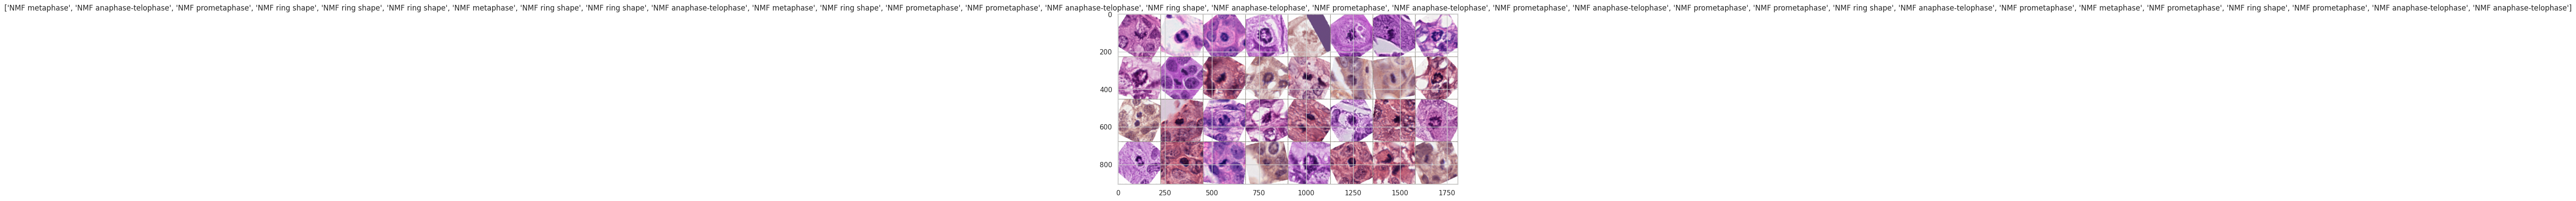

In [11]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Convert soft labels (float tensors) to integer class indices for display
# We use argmax to get the most prominent class from the soft label
imshow(out, title=[train_dataset.classes[x.item()] for x in classes])

Training the model
==================


In [12]:
# --- 1. The "Bounded Accuracy" Metric ---
def calc_bounded_accuracy(logits, targets, low_threshold=0.25, high_threshold_on_ambiguity=0.75):
    """
    Calculates accuracy with your strict rules:
    - False if confidence < 25%
    - False if confidence > 75% when experts disagree (ambiguity)
    """
    # Convert logits -> probabilities
    probs = torch.softmax(logits, dim=1)

    # Model prediction (Max confidence and Index)
    confidences, pred_idx = torch.max(probs, dim=1)

    # Expert value for the class chosen by the model
    target_vals = targets.gather(1, pred_idx.view(-1, 1)).squeeze()

    # A. Is it a class validated by at least one expert (>0) ?
    cond_valid = target_vals > 0

    # B. Does the model have at least 25% confidence?
    cond_confident = confidences >= low_threshold

    # C. Respect for ambiguity:
    # If the expert label is pure (>=0.9), 100% confidence is allowed.
    # Otherwise (disagreement), the model MUST NOT exceed 75% confidence.
    is_pure_target = target_vals >= 0.9
    respects_ambiguity = is_pure_target | (confidences <= high_threshold_on_ambiguity)

    # Result: All must be True
    correct_tensor = cond_valid & cond_confident & respects_ambiguity

    return correct_tensor.float().mean().item()

# --- 2. The Training Loop (Balanced Accuracy Version) ---
def train_model(model, dataloaders, criterion, optimizer, scheduler=None, num_epochs=25, save_path='best_model.pth'):
    since = time.time()

    # Keep a copy of initial weights
    best_model_wts = copy.deepcopy(model.state_dict())

    # We always save based on Loss (the most mathematically reliable)
    best_loss = float('inf')

    # History lists
    train_loss_history = []
    val_loss_history = []
    # History for Balanced Accuracy
    train_acc_history = []
    val_acc_history = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    print(f"Starting Training with Hard Labels on {device} for {num_epochs} epochs.")
    print("-" * 50)

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0

            # CHANGE: To calculate Balanced Accuracy, we need all predictions and labels for the epoch
            epoch_preds = []
            epoch_targets = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # CHANGE: Get the index of the predicted class (Hard Prediction)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics: Accumulate loss
                running_loss += loss.item() * inputs.size(0)

                # CHANGE: Store predictions and labels for later calculation using sklearn
                # We move them to CPU and convert to numpy immediately to save GPU memory
                epoch_preds.extend(preds.cpu().numpy())
                epoch_targets.extend(labels.cpu().numpy())

            # Scheduler step (only in train)
            if phase == 'train' and scheduler is not None:
                scheduler.step()

            # Epoch metrics calculation
            epoch_loss = running_loss / len(dataloaders[phase].dataset)

            # CHANGE: Calculate Balanced Accuracy using sklearn
            epoch_balanced_acc = balanced_accuracy_score(epoch_targets, epoch_preds)

            # Store history
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_balanced_acc)
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_balanced_acc)

            print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Balanced Acc: {epoch_balanced_acc*100:.2f}%')

            # Deep copy the model based on LOSS (Standard practice to avoid overfitting)
            if phase == 'val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), save_path)
                print(f"    -> New champion (Loss: {best_loss:.4f}) ! Saved as '{save_path}'")

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Loss: {best_loss:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Return model and history
    return model, train_loss_history, val_loss_history

Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [13]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(CONFIG['DEVICE'])
            labels = labels.to(CONFIG['DEVICE'])

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {train_dataset.classes[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.


In [14]:
def get_convnext_model(num_classes, mode='full'):
    """
    Loads ConvNeXt with 3 training strategies:
    - 'feature_extraction': Freezes everything except the last layer (Fast).
    - 'fine_tune': Freezes the beginning, trains the end (Compromise).
    - 'full': Trains the entire network (Maximum performance).
    """
    print(f"--- Loading {CONFIG['MODEL_TYPE']} model (Mode: {mode}) ---")

    # 1. Load pre-trained weights (ImageNet)
    # Use getattr to dynamically get the model based on CONFIG['MODEL_TYPE']
    model = getattr(models, CONFIG['MODEL_TYPE'])(weights='DEFAULT')

    # 2. Freezing Management
    if mode == 'feature_extraction':
        # Freeze the ENTIRE backbone
        for param in model.features.parameters():
            param.requires_grad = False
        print("-> Backbone FROZEN (only the head will be trained)")

    elif mode == 'fine_tune':
        # Freeze the first blocks, unfreeze the last one (Stage 4 = block '7')
        for name, child in model.features.named_children():
            if name != '7':
                for param in child.parameters():
                    param.requires_grad = False
            else:
                for param in child.parameters():
                    param.requires_grad = True
        print("-> Beginning of backbone FROZEN, Stage 4 UNLOCKED")

    else: # mode == 'full'
        print("-> Entire network is trainable")

    # 3. Replace the classification head
    # ConvNeXt: classifier[2] is the final linear layer
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model

In [15]:
# --- SETUP ---
model = get_convnext_model(num_classes=len(train_dataset.classes), mode=CONFIG['TRAIN'])
model = model.to(CONFIG['DEVICE']) # Ensure 'device' is defined (cuda/cpu)

# --- THE AVOIDED PITFALL ---
# We only pass to the optimizer the parameters that need to be learned
params_to_update = []
for name, param in model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)

print(f"Number of parameters to train : {len(params_to_update)}")

# The optimizer only works on the filtered list
optimizer = optim.AdamW(params_to_update, lr=CONFIG['LR'], weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

--- Loading convnext_tiny model (Mode: full) ---
-> Entire network is trainable
Number of parameters to train : 182


Train and evaluate
==================

In [ ]:
model_ft, train_history_loss, val_history_loss = train_model(model, dataloaders, criterion, optimizer, num_epochs=25)
plt.figure(figsize=(10, 5))
plt.plot(train_history_loss, label='Training Loss')
plt.plot(val_history_loss, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Starting Training with Hard Labels on cuda for 25 epochs.
--------------------------------------------------
Epoch 1/25
TRAIN Loss: 0.8992 | Balanced Acc: 59.39%
VAL Loss: 0.6266 | Balanced Acc: 79.25%
    -> New champion (Loss: 0.6266) ! Saved as 'best_model.pth'

Epoch 2/25
TRAIN Loss: 0.3636 | Balanced Acc: 86.69%
VAL Loss: 0.5419 | Balanced Acc: 77.30%
    -> New champion (Loss: 0.5419) ! Saved as 'best_model.pth'

Epoch 3/25
TRAIN Loss: 0.2606 | Balanced Acc: 90.78%
VAL Loss: 0.3246 | Balanced Acc: 80.82%
    -> New champion (Loss: 0.3246) ! Saved as 'best_model.pth'

Epoch 4/25
TRAIN Loss: 0.2155 | Balanced Acc: 91.74%
VAL Loss: 0.3972 | Balanced Acc: 85.63%

Epoch 5/25
TRAIN Loss: 0.1796 | Balanced Acc: 93.74%
VAL Loss: 0.4848 | Balanced Acc: 79.73%

Epoch 6/25
TRAIN Loss: 0.1436 | Balanced Acc: 94.83%
VAL Loss: 0.3115 | Balanced Acc: 73.27%
    -> New champion (Loss: 0.3115) ! Saved as 'best_model.pth'

Epoch 7/25
TRAIN Loss: 0.1274 | Balanced Acc: 95.50%
VAL Loss: 0.2933 | Bal

In [ ]:
visualize_model(model_ft)

In [ ]:
def evaluate_expert_comparison(model, loader, df_source, device):
    """
    Compares model predictions against Expert 1 and Expert 2 separately.

    Args:
        model: Trained PyTorch model.
        loader: DataLoader (must be shuffle=False to match DataFrame order).
        df_source: The original DataFrame corresponding to the loader (val_df or test_df).
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    all_preds = []

    print("Generating model predictions...")
    with torch.no_grad():
        for inputs, _ in loader: # We ignore the loader's soft labels here
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get the model's hard decision (Index of the max probability)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)

    # --- Retrieve Ground Truths (from DataFrame) ---
    # We need the Name -> Index mapping to convert CSV string labels to integers
    class_to_idx = loader.dataset.class_to_idx
    class_names = loader.dataset.classes

    # Convert DataFrame string columns to numerical indices
    y_true_exp1 = df_source['expert1_label'].map(class_to_idx).values
    y_true_exp2 = df_source['expert2_label'].map(class_to_idx).values

    # --- REPORT EXPERT 1 ---
    print("\n" + "="*60)
    print("🔍 RESULTS vs EXPERT 1")
    print("="*60)
    print(classification_report(y_true_exp1, all_preds, target_names=class_names))

    # --- REPORT EXPERT 2 ---
    print("\n" + "="*60)
    print("🔍 RESULTS vs EXPERT 2")
    print("="*60)
    print(classification_report(y_true_exp2, all_preds, target_names=class_names))

    # --- COMPARATIVE VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Confusion Matrix: Expert 1
    cm1 = confusion_matrix(y_true_exp1, all_preds)
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title("Confusion vs EXPERT 1")
    axes[0].set_xlabel("Model Prediction")
    axes[0].set_ylabel("True Label (Expert 1)")

    # Confusion Matrix: Expert 2
    cm2 = confusion_matrix(y_true_exp2, all_preds)
    sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title("Confusion vs EXPERT 2")
    axes[1].set_xlabel("Model Prediction")
    axes[1].set_ylabel("True Label (Expert 2)")

    plt.tight_layout()
    plt.show()

# --- HOW TO USE IT ---
# 1. Load your best trained model
model_ft.load_state_dict(torch.load('best_model.pth'))

# 2. Run evaluation (Ensure you pass the corresponding DataFrame!)
evaluate_expert_comparison(model_ft, val_loader, val_df, CONFIG['DEVICE'])

# Visualization of Neural Networks

This section aims at exploring different ways of visualizing Neural Networks:
- t-SNE of representations
- grad-CAM
- activation maximization

First, some preliminaries that facilitate plotting and data access on Google drive ... just execute !

In [ ]:
plt.rcParams['figure.figsize'] = (8.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Visualization of the encodings by t-SNE

We will first visualize the data.

In [ ]:
def plot_array(fig, dataset, classes_to_plot=None, samples_per_class=7):
    # --- CORRECTION ---
    # Your dataset doesn't have .targets, we build it ourselves:
    # 1. We retrieve the textual labels from the internal DataFrame
    all_labels_str = dataset.data['expert1_label'].values

    # 2. We convert them to integers (indices) using the dataset's dictionary
    # This is necessary for the sorting logic below to work
    Y = np.array([dataset.class_to_idx[l] for l in all_labels_str])
    # ------------------

    if classes_to_plot is None:
        classes_to_plot = np.unique(Y)

    num_classes = len(classes_to_plot)

    for k, y in enumerate(classes_to_plot):
        # We look for all indices corresponding to class y
        idxs = np.flatnonzero(Y == y)

        # Safety: don't ask for more images than available
        num_samples_to_draw = min(len(idxs), samples_per_class)

        if num_samples_to_draw > 0:
            idxs = np.random.choice(idxs, num_samples_to_draw, replace=False)

            for i, idx in enumerate(idxs):
                plt_idx = i * num_classes + k + 1
                ax = fig.add_subplot(samples_per_class, num_classes, plt_idx)

                # Retrieve the image (Tuple: image, label)
                img_tensor, _ = dataset[idx]

                # Display management (Tensor C,H,W -> Numpy H,W,C)
                # We denormalize visually if necessary (here simple conversion)
                image = img_tensor.permute((1, 2, 0)).cpu().numpy()

                # If the image is normalized (negative or small values), rescale for display
                image = image - image.min()
                image = image / image.max()

                ax.imshow(image)
                ax.axis('off')

                # Column title for the first row
                if i == 0:
                    class_name = dataset.classes[y]
                    ax.set_title(class_name, fontsize=10)

# --- Execution ---
fig = plt.figure(figsize=(12, 12))
# Use train_dataset or val_dataset depending on what you have loaded
plot_array(fig, val_dataset, samples_per_class=10)
plt.tight_layout()
plt.show()

Now, we will extract the features of a layer and visualize the distribution of the encodings with t-SNE.

In [ ]:
def visualize_tsne_dual_expert(model, loader, df_source, num_samples=2000):
    """
    Generates a t-SNE and displays it twice:
    - Once colored according to Expert 1
    - Once colored according to Expert 2
    Marks disagreements with 'x' crosses.
    """
    model.eval()
    device = CONFIG['DEVICE']

    features_list = []

    # 1. Feature Extraction (Downstream / Vector)
    print("Extracting features...")
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)

            # Pass through the backbone
            feat_map = model.features(inputs)
            # Pooling + Classifier Start
            x = model.avgpool(feat_map)
            x = model.classifier[0](x) # LayerNorm
            feat_vec = model.classifier[1](x) # Flatten

            features_list.append(feat_vec.cpu())

            # Stop if enough points have been collected (to avoid t-SNE being too long)
            if num_samples and len(features_list) * inputs.size(0) >= num_samples:
                break

    # Concatenation
    X_features = torch.cat(features_list, dim=0).numpy()

    # Slice the DataFrame to match the number of extracted features exactly
    # (In case we stopped before the end of the loader)
    n_points = X_features.shape[0]
    df_subset = df_source.iloc[:n_points].copy()

    # 2. t-SNE Calculation (Only once!)
    print(f"Calculating t-SNE on {n_points} points...")
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_features)

    # 3. Plot Data Preparation
    # Identify disagreements to change the marker style
    disagreement_mask = df_subset['expert1_label'] != df_subset['expert2_label']
    df_subset['marker_style'] = np.where(disagreement_mask, 'Disagreement', 'Agreement')

    # Get class names for the legend
    class_order = sorted(df_source['expert1_label'].unique())

    # 4. Double Display
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    # --- LEFT PLOT: EXPERT 1 ---
    sns.scatterplot(
        x=X_embedded[:, 0], y=X_embedded[:, 1],
        hue=df_subset['expert1_label'],
        style=df_subset['marker_style'], # Different shape for disagreement
        markers={'Agreement': 'o', 'Disagreement': 'X'},
        hue_order=class_order,
        palette='tab10', s=60, alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("t-SNE Projection viewed by EXPERT 1\n('X' marks disagreements with Expert 2)", fontsize=13)
    axes[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1), borderaxespad=0.)
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # --- RIGHT PLOT: EXPERT 2 ---
    sns.scatterplot(
        x=X_embedded[:, 0], y=X_embedded[:, 1],
        hue=df_subset['expert2_label'],
        style=df_subset['marker_style'],
        markers={'Agreement': 'o', 'Disagreement': 'X'},
        hue_order=class_order,
        palette='tab10', s=60, alpha=0.7, ax=axes[1]
    )
    axes[1].set_title("t-SNE Projection viewed by EXPERT 2\n(Geometry is identical, only colors change)", fontsize=13)
    # Hide the second legend to avoid visual redundancy, or leave it if desired
    axes[1].get_legend().remove()
    axes[1].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Note: use val_loader (shuffle=False) and val_df
visualize_tsne_dual_expert(model_ft, val_loader, val_df, num_samples=2000)

**Assignment**: Visualize now the embeddings at the two fully connected layers (in a different cell). Do you observe differences (albeit subtle)? Imagine you would like to use the same representations in another project (same image size, but other classes). Which of the representations seems more useful? Why?

In [ ]:
def visualize_upstream_downstream_comparison(model, loader, df_source, num_samples=2000):
    """
    Compares spatial organization (Upstream) vs Semantic (Downstream).
    Maintains marking of disagreements (Cross) to see where they are located.
    """
    model.eval()
    device = CONFIG['DEVICE']

    features_up_list = []
    features_down_list = []

    # 1. Extraction (Double extraction)
    print("Extracting Upstream AND Downstream features...")
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)

            # A. Upstream (Backbone Output)
            feat_map = model.features(inputs) # (Batch, 768, 7, 7)
            # Flatten for t-SNE: (Batch, 37632)
            feat_up_flat = feat_map.reshape(feat_map.size(0), -1)
            features_up_list.append(feat_up_flat.cpu())

            # B. Downstream (Just before classification)
            x = model.avgpool(feat_map)
            x = model.classifier[0](x) # LayerNorm
            feat_vec = model.classifier[1](x) # Flatten (Batch, 768)
            features_down_list.append(feat_vec.cpu())

            if num_samples and len(features_up_list) * inputs.size(0) >= num_samples:
                break

    # Convert to Numpy
    X_up = torch.cat(features_up_list, dim=0).numpy()
    X_down = torch.cat(features_down_list, dim=0).numpy()

    # Adjust DataFrame (in case we stopped before the end)
    n_points = X_up.shape[0]
    df_subset = df_source.iloc[:n_points].copy()

    # Prepare masks (Agreement/Disagreement)
    disagreement_mask = df_subset['expert1_label'] != df_subset['expert2_label']
    df_subset['marker_style'] = np.where(disagreement_mask, 'Disagreement', 'Agreement')
    class_order = sorted(df_source['expert1_label'].unique())

    # 2. Calculate both t-SNEs
    print("Computing Upstream t-SNE (The Eye)...")
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_emb_up = tsne.fit_transform(X_up)

    print("Computing Downstream t-SNE (The Brain)...")
    # Reinitialize t-SNE for the second run
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_emb_down = tsne.fit_transform(X_down)

    # 3. Comparative Display
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    # Common style parameters
    scatter_kwargs = {
        'hue': df_subset['expert1_label'],
        'style': df_subset['marker_style'],
        'markers': {'Agreement': 'o', 'Disagreement': 'X'},
        'hue_order': class_order,
        'palette': 'tab10',
        's': 60,
        'alpha': 0.8
    }

    # --- PLOT 1: UPSTREAM ---
    sns.scatterplot(x=X_emb_up[:, 0], y=X_emb_up[:, 1], ax=axes[0], **scatter_kwargs)
    axes[0].set_title("1. Raw Vision (Upstream)\n(Organization based on visual similarity)", fontsize=14)
    axes[0].get_legend().remove() # Remove legend here to lighten the plot
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # --- PLOT 2: DOWNSTREAM ---
    sns.scatterplot(x=X_emb_down[:, 0], y=X_emb_down[:, 1], ax=axes[1], **scatter_kwargs)
    axes[1].set_title("2. Semantic Vision (Downstream)\n(Organization based on biological class)", fontsize=14)
    # Keep legend only on the right
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.2, 1), title="Classes (Expert 1)")
    axes[1].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Usage
visualize_upstream_downstream_comparison(model_ft, val_loader, val_df, num_samples=2000)

**Assignment**: Visualize the tSNE plot of the untrained embeddings (model output before training). What do you observe?

In [ ]:
# Load the "Untrained" model (Default ImageNet weights)
# We use 'feature_extraction' mode to load the model without attaching an optimizer.
# This model has never seen your mitosis images.
print("Loading pre-trained model (ImageNet)...")
model_untrained = get_convnext_model(num_classes=len(train_dataset.classes), mode='feature_extraction')
model_untrained = model_untrained.to(CONFIG['DEVICE'])
model_untrained.eval()

# Reuse the existing dual-expert visualization function
visualize_tsne_dual_expert(model_untrained, val_loader, val_df, num_samples=2000)

# Classification activation maps (grad-CAM)

Classification activation maps provide certainly the most popular visualization methods for network inspection.

In [ ]:
torch.cuda.empty_cache()

labels_names = train_dataset.classes

Now, we load an image from the `AMI-Br` data base.

In [ ]:
filename = 'MIDOG21_194.png'
folder_name = 'data/patches/normal'

image = Image.open(os.path.join(folder_name, filename)).resize((224, 224))
plt.title('MIDOG21_194')
plt.imshow(image)

Now, we will predict the label of the image.

In [ ]:
preprocess = data_transforms['train']

img_prep = preprocess(image)
img_prep = img_prep.unsqueeze(0)

with torch.no_grad():
    img_prediction = model(img_prep.to(CONFIG['DEVICE']))

# Get probabilities by applying softmax to the output
probs = F.softmax(img_prediction, dim=1)

# Convert the probabilities to a numpy array and get the top 3 predictions
top_probs, top_indices = torch.topk(probs, 4, dim=1)
top_probs = top_probs.squeeze().cpu().numpy()
top_indices = top_indices.squeeze().cpu().numpy()

for i in range(3):
    label = labels_names[top_indices[i]]
    print(f"{label} ({top_indices[i]}): {top_probs[i] * 100:.2f}%")

# Get the solution index with the maximum probability
max_index = top_indices[0]
print('Predicted Index:', max_index)


We will use the [Grad-Cam++](https://arxiv.org/pdf/1710.11063) implementation from torch-cam https://github.com/frgfm/torch-cam

Note that the output of the model needs to be the the logits and not probabilities (default behaviour in torchvision models). The reason is that with `softmax` we cannot study the influence of neurons on the output, if the output depends on all classes (which is the case when we use `softmax`).

In [ ]:
def format_prediction_text(scores, class_names, top_k=3):
    """
    Formats prediction scores (or soft labels) into a readable string.

    Args:
        scores: A torch.Tensor (for soft labels) or numpy.ndarray (for probabilities).
        class_names: A list of class names.
        top_k: Number of top predictions to display for probabilities.
    """
    if isinstance(scores, torch.Tensor):
        # Handle soft labels (ground truth)
        active_classes_info = []
        for i, score in enumerate(scores):
            if score > 0: # Only consider classes that have a positive vote
                if scores.sum().item() == 1.0 and score.item() == 1.0: # If it's a hard label (sum is 1.0 and this is the only one)
                    active_classes_info.append(f"{class_names[i]}")
                elif scores.sum().item() > 0: # Soft labels with proportions
                    active_classes_info.append(f"{class_names[i]} ({score.item()*100:.0f}%)")
        return ", ".join(active_classes_info) if active_classes_info else "No Label"
    elif isinstance(scores, np.ndarray):
        # Handle predicted probabilities
        sorted_indices = np.argsort(scores)[::-1]
        top_predictions = []
        for i in range(min(top_k, len(sorted_indices))):
            idx = sorted_indices[i]
            prob = scores[idx]
            top_predictions.append(f"{class_names[idx]} ({prob*100:.2f}%)")
        return ", ".join(top_predictions)
    else:
        return "Invalid score format"

def visualize_explanation_simple(model, dataset, idx, device):
    """
    Cleaned up version: Simply displays the text above the image.
    """
    model.eval()

    # --- CRITICAL FIX: Force gradient activation for Grad-CAM ---
    with torch.set_grad_enabled(True):

        # 1. Data
        img_tensor, label_vector = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # 2. Prediction
        output = model(input_tensor)
        # .detach() is important here because we activated gradients
        pred_probs = torch.softmax(output, dim=1).cpu().detach().numpy()[0]

        # 3. Texts
        # (Assuming format_prediction_text is defined in a previous cell)
        gt_text = format_prediction_text(label_vector, dataset.classes)
        pred_text = format_prediction_text(pred_probs, dataset.classes)

        # 4. Grad-CAM++ (With context manager to clean up hooks)
        target_layers = [model.features[-1][-1]]

        # Using 'with' to avoid conflicts if the cell is re-run
        with GradCAMPlusPlus(model=model, target_layers=target_layers) as cam:
            target_class = np.argmax(pred_probs)
            # Generate CAM
            grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]

    # 5. Denormalization (Outside gradient calculation, for display only)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

    # --- DISPLAY (Identical to your request) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # LEFT: TRUTH
    axes[0].imshow(img_display)
    axes[0].set_title(f"Image #{idx} - Truth (Experts)\n\n{gt_text}",
                      fontsize=11, loc='left')
    axes[0].axis('off')

    # RIGHT: PREDICTION
    axes[1].imshow(visualization)
    axes[1].set_title(f"Grad-CAM++ (Focus: {dataset.classes[target_class]})\n\n{pred_text}",
                      fontsize=11, loc='left', color='darkblue')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Immediate test
# Note: I added transform=inference_transforms because the model needs
# normalized tensors to make a correct prediction (and for .unsqueeze to work).
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
vis_dataset = MitosisDataset(
    train_df,
    root_dir=ROOT_DIR,
    transform=inference_transforms
)

# Pick a random image to test
random_idx = random.randint(0, len(vis_dataset)-1)
visualize_explanation_simple(model_ft, vis_dataset, random_idx, device=CONFIG['DEVICE'])

In [ ]:
def plot_soft_confusion_matrix(model, loader, device, classes):
    model.eval()

    # 1. Accumulate all probabilities and label vectors
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device) # Shape (Batch, Classes) e.g., [0, 0.5, 0.5, 0]

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_preds.append(probs.cpu())
            all_labels.append(labels.cpu())

    # Concatenate everything -> (N_samples, N_classes)
    y_pred = torch.cat(all_preds, dim=0)
    y_true = torch.cat(all_labels, dim=0)

    # 2. The magic calculation (Matrix Product)
    # Transpose of True (Classes, N) x Pred (N, Classes) -> (Classes, Classes)
    cm_soft = torch.matmul(y_true.T, y_pred)

    # 3. Normalization (to get %)
    # Divide by the sum of real masses for each class (Total "Expert Mass")
    # .unsqueeze(1) allows dividing each row by its total
    cm_norm = cm_soft / y_true.sum(dim=0).unsqueeze(1)

    # Convert to Numpy for display
    cm_np = cm_norm.numpy()

    # 4. Heatmap Display
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_np, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title("Soft Confusion Matrix\n(Probability Mass Distribution)")
    plt.xlabel("Model Predicted Distribution")
    plt.ylabel("Truth Distribution (Experts)")
    plt.show()

# Usage
plot_soft_confusion_matrix(model_ft, val_loader, CONFIG['DEVICE'], train_dataset.classes)

In [ ]:
def analyze_uncertainty(model, loader, device):
    model.eval()
    entropies_agreement = []
    entropies_disagreement = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            labels = labels.cpu().numpy()

            # Calculate entropy for each prediction (Model Uncertainty)
            # High entropy = flat distribution [0.3, 0.3, 0.4]
            # Low entropy = sharp peak [0.9, 0.05, 0.05]
            batch_entropies = entropy(probs, axis=1)

            # Separate based on whether experts agreed or not
            for i in range(len(labels)):
                max_val = labels[i].max()

                if max_val > 0.9: # Agreement (1.0)
                    entropies_agreement.append(batch_entropies[i])
                else: # Disagreement (0.5)
                    entropies_disagreement.append(batch_entropies[i])

    # Display
    plt.figure(figsize=(8, 6))
    plt.hist(entropies_agreement, bins=30, alpha=0.5, label='Experts Agreed (Consensus)', density=True)
    plt.hist(entropies_disagreement, bins=30, alpha=0.5, label='Experts Disagreed', density=True)
    plt.xlabel("Model Uncertainty (Entropy)")
    plt.ylabel("Density")
    plt.title("Does the model learn to doubt when necessary?")
    plt.legend()
    plt.show()

# Usage
analyze_uncertainty(model_ft, val_loader, CONFIG['DEVICE'])

In [ ]:
def evaluate_by_groups(model, loader, df_source, device):
    """
    Separate analysis:
    - Group A: Experts agree (Consensus)
    - Group B: Experts disagree (Ambiguity)
    """
    model.eval()

    # Storage
    all_preds_idx = []
    all_confidences = [] # To see if the model "doubts"

    print("Group analysis in progress...")
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get probabilities (Softmax) to check confidence
            probs = torch.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, dim=1)

            all_preds_idx.extend(preds.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    # Convert to numpy
    all_preds_idx = np.array(all_preds_idx)
    all_confidences = np.array(all_confidences)

    # --- 1. GROUP SEPARATION VIA DATAFRAME ---
    # Recreate masks based on source DataFrame (aligned with loader shuffle=False)
    mask_agreement = (df_source['expert1_label'] == df_source['expert2_label']).values
    mask_disagreement = ~mask_agreement

    print(f"\nDistribution: {mask_agreement.sum()} Agreement cases (A) / {mask_disagreement.sum()} Disagreement cases (B)")

    # --- 2. GROUP A ANALYSIS (AGREEMENT) ---
    # Here, the truth is simple: Expert 1 = Expert 2
    y_true_A = df_source.loc[mask_agreement, 'expert1_label'].map(loader.dataset.class_to_idx).values
    preds_A = all_preds_idx[mask_agreement]
    conf_A = all_confidences[mask_agreement]

    acc_A = accuracy_score(y_true_A, preds_A)
    print(f"\n✅ GROUP A (Consensus) - Accuracy : {acc_A*100:.2f}%")
    print(f"   -> Average Model Confidence : {conf_A.mean()*100:.1f}%")

    # --- 3. GROUP B ANALYSIS (DISAGREEMENT) ---
    # Here, we use "Relaxed Accuracy": Correct if model == Exp1 OR model == Exp2
    y_true_B1 = df_source.loc[mask_disagreement, 'expert1_label'].map(loader.dataset.class_to_idx).values
    y_true_B2 = df_source.loc[mask_disagreement, 'expert2_label'].map(loader.dataset.class_to_idx).values
    preds_B = all_preds_idx[mask_disagreement]
    conf_B = all_confidences[mask_disagreement]

    # Calculate Relaxed Accuracy: (Pred == Exp1) OR (Pred == Exp2)
    # Since Exp1 != Exp2, these conditions are mutually exclusive, we can sum booleans
    is_correct_relaxed = (preds_B == y_true_B1) | (preds_B == y_true_B2)
    acc_B_relaxed = is_correct_relaxed.mean()

    print(f"\n⚠️ GROUP B (Disagreement) - Relaxed Accuracy : {acc_B_relaxed*100:.2f}%")
    print(f"   (The model agrees with at least one of the two experts)")
    print(f"   -> Average Model Confidence : {conf_B.mean()*100:.1f}%")

    # --- 4. VISUALIZATION: LEARNED "DOUBT" ---
    plt.figure(figsize=(10, 6))
    sns.kdeplot(conf_A, fill=True, label='Group A (Consensus)', color='green', clip=(0,1))
    sns.kdeplot(conf_B, fill=True, label='Group B (Disagreement)', color='orange', clip=(0,1))

    plt.title("Model Confidence Distribution\n(Did the model learn to doubt on difficult cases?)", fontsize=13)
    plt.xlabel("Prediction Confidence (Max Probability)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- USAGE ---
evaluate_by_groups(model_ft, val_loader, val_df, CONFIG['DEVICE'])

In [ ]:
# --- 0. PREPARATION ---
print("📢 Launching full test battery on TEST SET...")
device = CONFIG['DEVICE']
# Ensure the best model is loaded
try:
    model_ft.load_state_dict(torch.load('best_model.pth', map_location=device))
    print("✅ 'best_model.pth' weights loaded.")
except:
    print("⚠️ Warning: Weights not found, using current model.")

model_ft.eval()

# --- 1. METRICS & MATRICES (Classic vs Experts) ---
print("\n" + "="*40 + "\n1️⃣ COMPARISON WITH EXPERTS (Matrices)\n" + "="*40)
evaluate_expert_comparison(model_ft, test_loader, test_df, device)

# --- 2. GROUP ANALYSIS (Consensus vs Ambiguity) ---
print("\n" + "="*40 + "\n2️⃣ GROUP PERFORMANCE (Agreement/Disagreement)\n" + "="*40)
evaluate_by_groups(model_ft, test_loader, test_df, device)

# --- 3. UNCERTAINTY (Entropy) ---
print("\n" + "="*40 + "\n3️⃣ CALIBRATION & UNCERTAINTY (Entropy)\n" + "="*40)
analyze_uncertainty(model_ft, test_loader, device)

# --- 4. SOFT CONFUSION MATRIX (Relevant for Soft model, but works for both) ---
print("\n" + "="*40 + "\n4️⃣ PROBABILISTIC CONFUSION MATRIX\n" + "="*40)
plot_soft_confusion_matrix(model_ft, test_loader, device, train_dataset.classes)

# --- 5. t-SNE VISUALIZATION (Latent Space) ---
print("\n" + "="*40 + "\n5️⃣ t-SNE: SPACE REPRESENTATION\n" + "="*40)
# We can limit num_samples if the test set is huge, otherwise None to take all
visualize_tsne_dual_expert(model_ft, test_loader, test_df, num_samples=None)

print("\n" + "="*40 + "\n6️⃣ t-SNE: 'EYE' VISION (Features) vs 'BRAIN' (Classifier)\n" + "="*40)
visualize_upstream_downstream_comparison(model_ft, test_loader, test_df, num_samples=None)

# --- 6. GRAD-CAM (Explainability on a few images) ---
print("\n" + "="*40 + "\n7️⃣ GRAD-CAM: RANDOM EXAMPLES FROM TEST SET\n" + "="*40)
# Displaying 3 random examples from the test set
indices = random.sample(range(len(test_dataset)), 3)
for idx in indices:
    print(f"--- Explainability for Test image index {idx} ---")
    visualize_explanation_simple(model_ft, test_dataset, idx, device)